Title: Contribution_RL_Days_seasons.ipynb

Purpose: Look how the different components (wind, solar, demand) contribute to the residual load days

Author: Onno Nennecke on 03.09.2025 Modified: 24.09.2025

Input data: 

- Combined model output: model_output_adj.nc
    - This file lies here: /climca/people/onennecke/model_output/not_bias_corrected/model_output_adj.nc

Output data:

- Plot: 
    - This file lies here: /home/onennecke/Code/Figures/

In [2]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib import colors, cm
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec
from mpl_toolkits.mplot3d import Axes3D  # registers 3D projection

In [3]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_adj.nc'
files = [path]

ds = xr.open_dataset(path)

ts_datasets = ds.where((ds.ESM_run != 'ERA5_hist_wwd') & (ds.ESM_run != 'SMARD_hist'),drop=True)
ts_datasets.load()

# ds_ERA5 = ds.where(ds.ESM_run == 'ERA5_hist_week', drop=True)
# ds_ERA5.load()

# ds_SMARD = ds.where(ds.ESM_run == 'SMARD_hist', drop=True)
# ds_SMARD.load()
# ts_datasets

<xarray.Dataset> Size: 42MB
Dimensions:            (ESM_run: 100, time: 3650)
Coordinates:
    crs                int64 8B 4326
    gridtype           <U6 24B 'lonlat'
  * time               (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM                (ESM_run) <U13 5kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run                (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2'
  * ESM_run            (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0...
    country            float64 8B 9.0
    period             (ESM_run) <U4 2kB 'week' 'week' 'week' ... 'week' 'week'
    doy                (time) int64 29kB 1 2 3 4 5 6 ... 360 361 362 363 364 365
Data variables: (12/16)
    temp               (ESM_run, time) float64 3MB 2.862 -0.3492 ... 6.307 3.968
    demand             (ESM_run, time) float64 3MB 1.485e+03 ... 1.471e+03
    sfcWind            (ESM_run, time) float64 3MB 8.056 6.177 ... 10.63 9.856
    rsds               (ESM_run, time) float32 1MB 13.75 24.11 ... 17.57 21.48
    tas                (ESM_run, time) float32 1MB 2.114 -0.7924 ... 6.209 4.354
    tasmax             (ESM_run, time) float32 1MB 4.033 0.7523 ... 7.664 5.364
    ...                 ...
    Netto              (ESM_run, time) float64 3MB -792.1 -923.2 ... -165.9
    Residual_load      (ESM_run, time) float64 3MB 792.1 923.2 ... 64.31 165.9
    solar_prod_adj     (ESM_run, time) float64 3MB -12.15 2.315 ... 0.2677
    total_prod_adj     (ESM_run, time) float64 3MB 647.0 543.7 ... 1.249e+03
    Netto_adjusted     (ESM_run, time) float64 3MB -837.6 -980.6 ... -221.5
    Residual_load_adj  (ESM_run, time) float64 3MB 837.6 980.6 ... 115.4 221.5

In [4]:
# --- 2) Extract the three time series arrays [ESM_run, time] ---
# wind = ts_datasets['wind_off_prod_adj'] + ts_datasets['wind_on_prod_adj']
solar = ts_datasets['solar_prod_adj']
total = ts_datasets['total_prod_adj']
# demand = ts_datasets['demand']
res_load = ts_datasets['Residual_load_adj']
wind = ts_datasets['wind_off_prod'] + ts_datasets['wind_on_prod']
# solar = ts_datasets['solar_prod']
# total = ts_datasets['total_prod']
demand = ts_datasets['demand']
# res_load = ts_datasets['Residual_load']

# Thresholds
wind_thresh = np.quantile(wind.values.flatten(), 0.05)
solar_thresh = np.quantile(solar.values.flatten(), 0.05)
total_thresh = np.quantile(total.values.flatten(), 0.05)
demand_thresh = np.quantile(demand.values.flatten(), 0.95)
res_load_thresh = np.quantile(res_load.values.flatten(), 0.95)

# --- 3) Pull out the doy coordinate for x-axis ---
x = ts_datasets['doy']

# --- 4) Compute the mean winter cycle (averaged over runs & winters) ---
# mean_wind  = wind.groupby(x).mean(dim=['ESM_run','time'])
# mean_solar = solar.groupby(x).mean(dim=['ESM_run','time'])
# mean_total = total.groupby(x).mean(dim=['ESM_run','time'])
# mean_demand = demand.groupby(x).mean(dim=['ESM_run','time'])
# mean_res_load = res_load.groupby(x).mean(dim=['ESM_run','time'])


In [5]:
# Extreme event days:
extreme_res_load = ts_datasets.where(ts_datasets['Residual_load_adj'] > res_load_thresh)
extreme_res_load

<xarray.Dataset> Size: 42MB
Dimensions:            (ESM_run: 100, time: 3650)
Coordinates:
    crs                int64 8B 4326
    gridtype           <U6 24B 'lonlat'
  * time               (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM                (ESM_run) <U13 5kB 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run                (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2'
  * ESM_run            (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0...
    country            float64 8B 9.0
    period             (ESM_run) <U4 2kB 'week' 'week' 'week' ... 'week' 'week'
    doy                (time) int64 29kB 1 2 3 4 5 6 ... 360 361 362 363 364 365
Data variables: (12/16)
    temp               (ESM_run, time) float64 3MB nan nan nan ... nan nan nan
    demand             (ESM_run, time) float64 3MB nan nan nan ... nan nan nan
    sfcWind            (ESM_run, time) float64 3MB nan nan nan ... nan nan nan
    rsds               (ESM_run, time) float32 1MB nan nan nan ... nan nan nan
    tas                (ESM_run, time) float32 1MB nan nan nan ... nan nan nan
    tasmax             (ESM_run, time) float32 1MB nan nan nan ... nan nan nan
    ...                 ...
    Netto              (ESM_run, time) float64 3MB nan nan nan ... nan nan nan
    Residual_load      (ESM_run, time) float64 3MB nan nan nan ... nan nan nan
    solar_prod_adj     (ESM_run, time) float64 3MB nan nan nan ... nan nan nan
    total_prod_adj     (ESM_run, time) float64 3MB nan nan nan ... nan nan nan
    Netto_adjusted     (ESM_run, time) float64 3MB nan nan nan ... nan nan nan
    Residual_load_adj  (ESM_run, time) float64 3MB nan nan nan ... nan nan nan

In [6]:
# 1) Convert dataset to a long DataFrame
df = ts_datasets.to_dataframe().reset_index()   # columns will include ESM_run, time, ESM, run, variables...

df['winter'] = np.where(df['time'].dt.month.isin([10, 11, 12, 1, 2, 3]), 1, 0)

df['summer'] = np.where(df['time'].dt.month.isin([4, 5, 6, 7, 8, 9]), 1, 0)

df['winter_short'] = np.where(df['time'].dt.month.isin([12, 1, 2]), 1, 0)
df['summer_short'] = np.where(df['time'].dt.month.isin([6, 7, 8]), 1, 0)
df['spring_short'] = np.where(df['time'].dt.month.isin([3, 4, 5]), 1, 0)
df['autumn_short'] = np.where(df['time'].dt.month.isin([9, 10, 11]), 1, 0)


df['wind_total'] = df['wind_off_prod'] + df['wind_on_prod']

# Filter by the threshold
df_winter = df[df['winter'] == 1]
# Drop any remaining rows with NaNs across any column
df_winter = df_winter.dropna(how='any').reset_index(drop=True)

df_summer = df[df['summer'] == 1]
df_summer = df_summer.dropna(how='any').reset_index(drop=True)

df_winter_short = df[df['winter_short'] == 1]
df_winter_short = df_winter_short.dropna(how='any').reset_index(drop=True)
df_summer_short = df[df['summer_short'] == 1]
df_summer_short = df_summer_short.dropna(how='any').reset_index(drop=True)
df_spring_short = df[df['spring_short'] == 1]
df_spring_short = df_spring_short.dropna(how='any').reset_index(drop=True)
df_autumn_short = df[df['autumn_short'] == 1]
df_autumn_short = df_autumn_short.dropna(how='any').reset_index(drop=True)

# Filter by the threshold
df_filtered = df[df['Residual_load_adj'] > res_load_thresh]

# Drop any remaining rows with NaNs across any column
df_filtered = df_filtered.dropna(how='any').reset_index(drop=True)



# df_filtered is now a tidy pandas DataFrame: one row per selected event
print(df_filtered.shape)
df_filtered.head()


(18250, 32)


,ESM_run,time,temp,demand,sfcWind,rsds,tas,tasmax,wind_off_prod,wind_on_prod,...,country,period,doy,winter,summer,winter_short,summer_short,spring_short,autumn_short,wind_total
0,ACCESS-CM2_r1i1p1f1,2015-01-05,0.245598,1516.886409,4.147174,21.248137,0.787202,1.800007,61.849189,38.052098,...,9.0,week,5,1,0,1,0,0,0,99.901288
1,ACCESS-CM2_r1i1p1f1,2015-01-07,-3.086905,1557.932764,4.904704,27.715582,-2.206280,-0.751457,32.787723,77.997430,...,9.0,week,7,1,0,1,0,0,0,110.785153
2,ACCESS-CM2_r1i1p1f1,2015-01-08,-3.234493,1559.748740,3.830855,30.455936,-2.128153,-0.627887,38.036532,25.855025,...,9.0,week,8,1,0,1,0,0,0,63.891557
3,ACCESS-CM2_r1i1p1f1,2015-01-18,1.290212,1503.988486,2.607071,29.728300,1.512397,2.677035,17.668979,8.302006,...,9.0,week,18,1,0,1,0,0,0,25.970985
4,ACCESS-CM2_r1i1p1f1,2015-01-19,0.318840,1515.982819,3.103404,33.742901,0.572515,1.431716,10.574485,8.894297,...,9.0,week,19,1,0,1,0,0,0,19.468783


### Density curves

/tmp/ipykernel_2816574/2171436014.py:85: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.18)  # make room for the legend


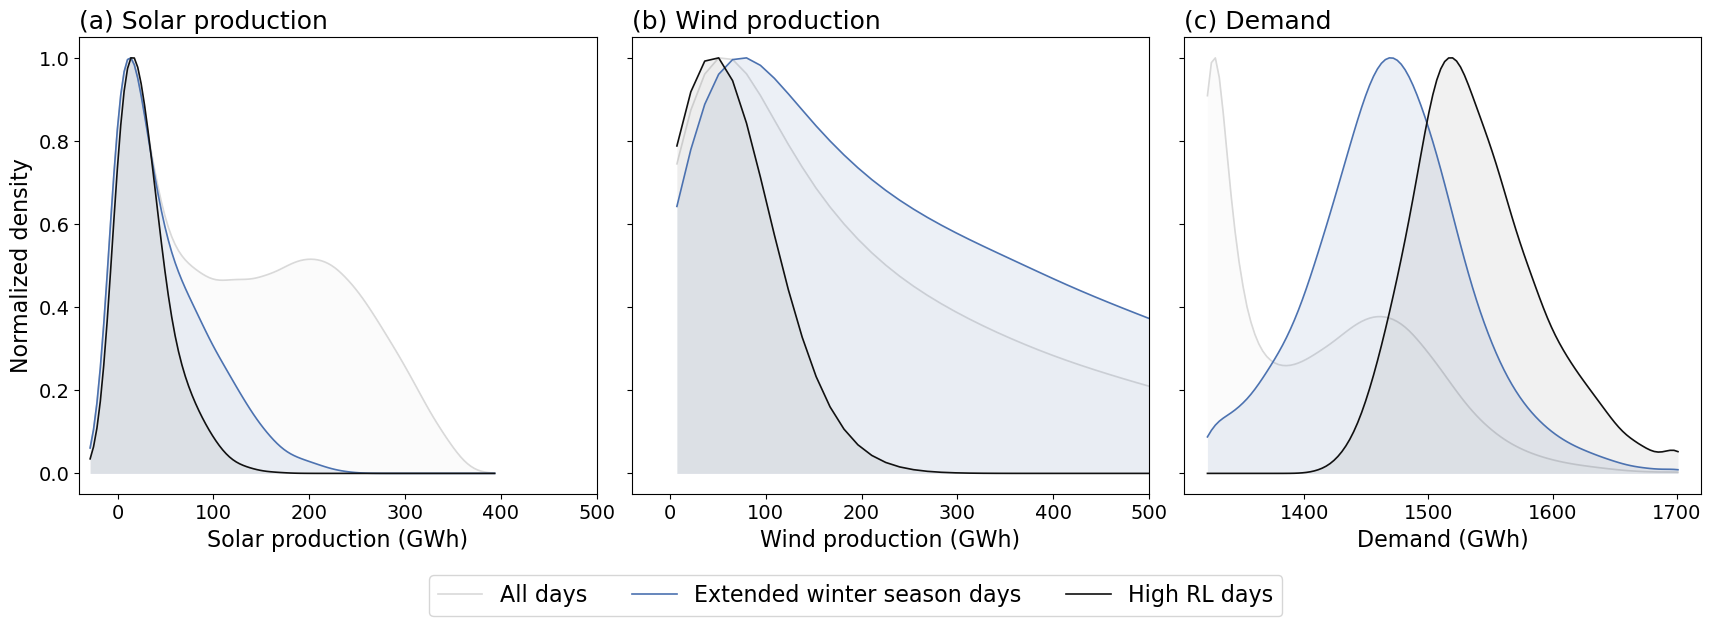

In [14]:
# variables and appearance
columns = [('solar_prod_adj','(a) Solar production', 'Solar production (GWh)'), ('wind_total','(b) Wind production', 'Wind production (GWh)'), ('demand','(c) Demand', 'Demand (GWh)')]  # cols and pretty names
bins = 120  # number of histogram bins
smooth_sigma = 3  # smoothing bandwidth (larger = smoother)
figsize = (17,5.5)  # figure size
color_all, color_winter, color_filtered = '#d9d9d9','#4c72b0','#111111'  # colors
lw = 1.2  # line width
fill_alpha = 0.10  # fill transparency

# helper: gaussian kernel (precompute once) ------------------------------------------------
kernel_half = max(1, int(3*smooth_sigma))  # half-width of kernel
k_x = np.arange(-kernel_half, kernel_half+1)  # kernel x coords
kernel = np.exp(-0.5*(k_x/smooth_sigma)**2)  # gaussian weights
kernel = kernel / kernel.sum()  # normalize kernel to sum=1
# -----------------------------------------------------------------------------------------


# make text bigger (global)
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})


# plotting
fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=True)  # 3 subplots in a row

for ax, (col, title, xaxis) in zip(axes, columns):
    a = df[col].values  # all data array
    w = df_winter[col].values  # winter array
    f = df_filtered[col].values  # filtered/high-RL array

    # common bin edges spanning min..max across all 3 sets so curves align
    combined_min = min(a.min(), w.min(), f.min())  # global min
    combined_max = max(a.max(), w.max(), f.max())  # global max
    edges = np.linspace(combined_min, combined_max, bins+1)  # bin edges
    centers = (edges[:-1] + edges[1:]) / 2.0  # bin centers

    # histogram densities (density=True -> density per unit)
    ca, _ = np.histogram(a, bins=edges, density=True)  # density for all
    cw, _ = np.histogram(w, bins=edges, density=True)  # density for winter
    cf, _ = np.histogram(f, bins=edges, density=True)  # density for filtered

    # smooth densities by convolving with the gaussian kernel
    sa = np.convolve(ca, kernel, mode='same')  # smoothed all
    sw = np.convolve(cw, kernel, mode='same')  # smoothed winter
    sf = np.convolve(cf, kernel, mode='same')  # smoothed filtered

    # normalize each curve to its own peak so every curve's max == 1
    sa /= max(sa.max(), 1e-12)  # normalize all
    sw /= max(sw.max(), 1e-12)  # normalize winter
    sf /= max(sf.max(), 1e-12)  # normalize filtered

    # plotting curves + fills
    ax.plot(centers, sa, lw=lw, color=color_all, label='All', zorder=1)  # all curve
    ax.fill_between(centers, sa, 0, color=color_all, alpha=fill_alpha, linewidth=0)  # fill all

    ax.plot(centers, sw, lw=lw, color=color_winter, label='Winter', zorder=2)  # winter curve
    ax.fill_between(centers, sw, 0, color=color_winter, alpha=fill_alpha, linewidth=0)  # fill winter

    ax.plot(centers, sf, lw=lw, color=color_filtered, label='High RL', zorder=3)  # filtered curve
    ax.fill_between(centers, sf, 0, color=color_filtered, alpha=0.06, linewidth=0)  # fill filtered

    # labels and styling
    ax.set_title(title, loc='left')  # subplot title
    ax.set_xlabel(xaxis)  # x label
    if ax == axes[0]:
        ax.set_ylabel('Normalized density')  # y label    ax.grid(True, linestyle=':', alpha=0.4)  # grid
    if ax == axes[0] or ax == axes[1]:
        ax.set_xlim(-40, 500)  # y limits only on first subplot
    # ax.legend(fontsize='small')  # legend

# fig.suptitle('Smoothed distributions — All / Winter / High RL (each peak = 1)', y=1.04, fontsize=18)  # overall title

legend_handles = [
    Line2D([0], [0], color=color_all, lw=lw, label='All days'),
    Line2D([0], [0], color=color_winter, lw=lw, label='Extended winter season days'),
    Line2D([0], [0], color=color_filtered, lw=lw, label='High RL days'),
]
fig.subplots_adjust(bottom=0.18)  # make room for the legend
fig.legend(handles=legend_handles, loc='lower center', ncol=3,
           bbox_to_anchor=(0.5, -0.13), fontsize=16, frameon=True)

# plt.savefig('/home/onennecke/Code/Figures/Contr_RL_Days_dens_curves_2.png', bbox_inches='tight', dpi=300)

plt.show()  # display


/tmp/ipykernel_2721016/2840094949.py:122: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.18)  # make room for the legend


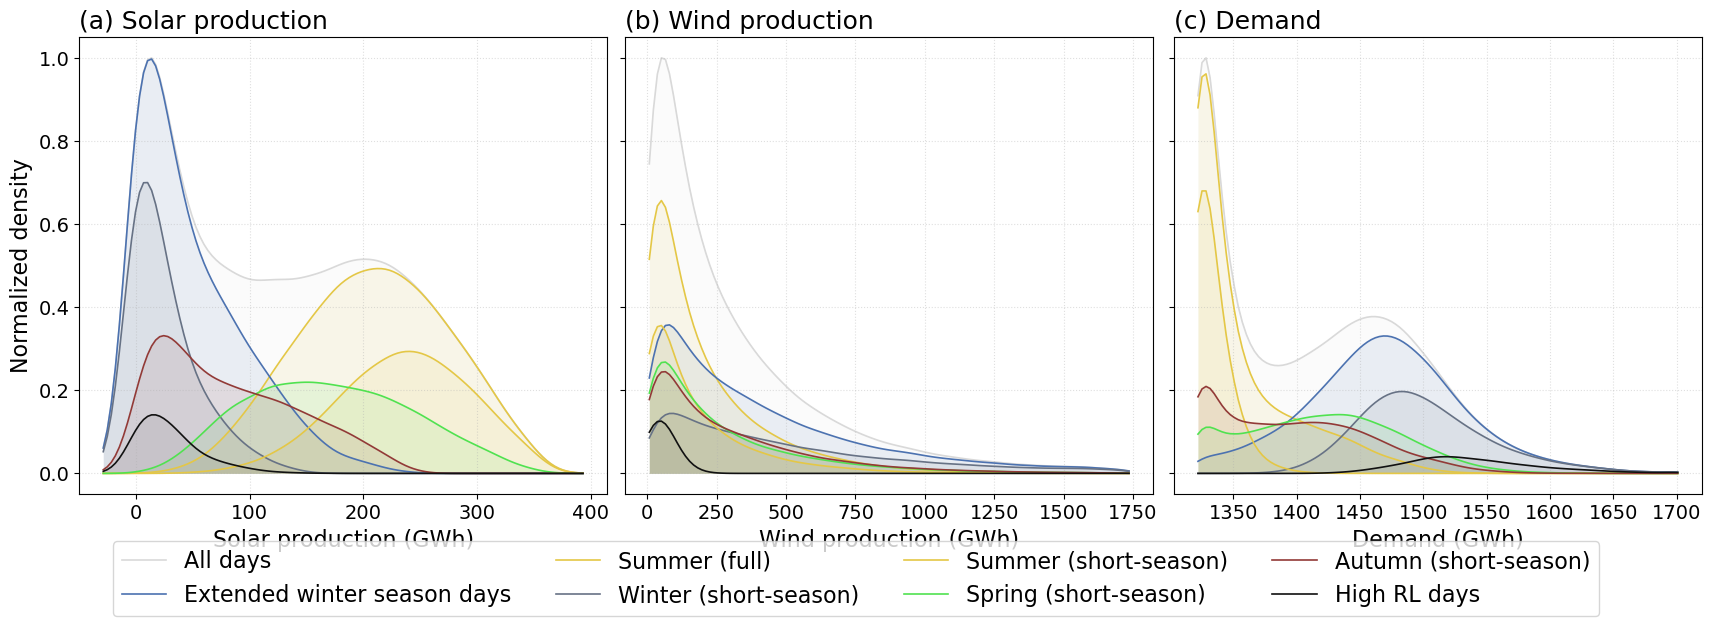

In [6]:
# variables and appearance
columns = [('solar_prod_adj','(a) Solar production', 'Solar production (GWh)'), ('wind_total','(b) Wind production', 'Wind production (GWh)'), ('demand','(c) Demand', 'Demand (GWh)')]  # cols and pretty names
bins = 120  # number of histogram bins
smooth_sigma = 3  # smoothing bandwidth (larger = smoother)
figsize = (17,5.5)  # figure size
color_all, color_winter, color_filtered, color_winter_short, color_summer_short, color_spring_short, color_autumn_short = '#d9d9d9','#4c72b0','#111111', "#677285", "#e4c746", "#50e250", "#923a37"  # colors
lw = 1.2  # line width
fill_alpha = 0.10  # fill transparency

# helper: gaussian kernel (precompute once) ------------------------------------------------
kernel_half = max(1, int(3*smooth_sigma))  # half-width of kernel
k_x = np.arange(-kernel_half, kernel_half+1)  # kernel x coords
kernel = np.exp(-0.5*(k_x/smooth_sigma)**2)  # gaussian weights
kernel = kernel / kernel.sum()  # normalize kernel to sum=1
# -----------------------------------------------------------------------------------------


# make text bigger (global)
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})
# plotting (updated to include all requested datasets)
fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=True)  # 3 subplots in a row

for ax, (col, title, xaxis) in zip(axes, columns):
    a = df[col].values  # all data array
    w = df_winter[col].values  # winter array
    su = df_summer[col].values  # summer (full) array
    ws_short = df_winter_short[col].values  # winter short-season array
    ss_short = df_summer_short[col].values  # summer short-season array
    spr_short = df_spring_short[col].values  # spring short-season array
    aut_short = df_autumn_short[col].values  # autumn short-season array
    f = df_filtered[col].values  # filtered/high-RL array

    # common bin edges spanning min..max across all sets so curves align
    combined_min = min(a.min(), w.min(), su.min(), ws_short.min(), ss_short.min(), spr_short.min(), aut_short.min(), f.min())
    combined_max = max(a.max(), w.max(), su.max(), ws_short.max(), ss_short.max(), spr_short.max(), aut_short.max(), f.max())
    edges = np.linspace(combined_min, combined_max, bins+1)  # bin edges
    centers = (edges[:-1] + edges[1:]) / 2.0  # bin centers

    # histogram counts (density=False -> raw counts) computed on the same edges
    ca, _ = np.histogram(a, bins=edges, density=False)       # counts for all
    cw, _ = np.histogram(w, bins=edges, density=False)       # counts for winter
    csu, _ = np.histogram(su, bins=edges, density=False)     # counts for summer (full)
    cws_short, _ = np.histogram(ws_short, bins=edges, density=False)  # counts for winter short
    css_short, _ = np.histogram(ss_short, bins=edges, density=False)  # counts for summer short
    cspr_short, _ = np.histogram(spr_short, bins=edges, density=False) # counts for spring short
    caut_short, _ = np.histogram(aut_short, bins=edges, density=False) # counts for autumn short
    cf, _ = np.histogram(f, bins=edges, density=False)       # counts for filtered

    # smooth counts by convolving with the gaussian kernel
    sa = np.convolve(ca, kernel, mode='same')       # smoothed all
    sw = np.convolve(cw, kernel, mode='same')       # smoothed winter
    ssu = np.convolve(csu, kernel, mode='same')     # smoothed summer (full)
    sws_short = np.convolve(cws_short, kernel, mode='same')  # smoothed winter short
    sss_short = np.convolve(css_short, kernel, mode='same')  # smoothed summer short
    sspr_short = np.convolve(cspr_short, kernel, mode='same')# smoothed spring short
    saut_short = np.convolve(caut_short, kernel, mode='same')# smoothed autumn short
    sf = np.convolve(cf, kernel, mode='same')       # smoothed filtered

    # normalize so the largest peak among all equals 1
    peak = max(sa.max(), sw.max(), ssu.max(), sws_short.max(), sss_short.max(), sspr_short.max(), saut_short.max(), sf.max(), 1e-12)
    sa /= peak
    sw /= peak
    ssu /= peak
    sws_short /= peak
    sss_short /= peak
    sspr_short /= peak
    saut_short /= peak
    sf /= peak

    # plotting curves + fills (kept original 'All' / 'Winter' / 'High RL' style but added the others)
    ax.plot(centers, sa, lw=lw, color=color_all, label='All', zorder=1)  # all curve
    ax.fill_between(centers, sa, 0, color=color_all, alpha=fill_alpha, linewidth=0)  # fill all

    ax.plot(centers, sw, lw=lw, color=color_winter, label='Winter', zorder=3)  # winter curve
    ax.fill_between(centers, sw, 0, color=color_winter, alpha=fill_alpha, linewidth=0)  # fill winter

    # use the provided short-season colors for both full summer and short-season where a dedicated color wasn't provided
    ax.plot(centers, ssu, lw=lw, color=color_summer_short, label='Summer (full)', zorder=2)  # summer (full)
    ax.fill_between(centers, ssu, 0, color=color_summer_short, alpha=fill_alpha, linewidth=0)

    ax.plot(centers, sws_short, lw=lw, color=color_winter_short, label='Winter (short)', zorder=4)  # winter short
    ax.fill_between(centers, sws_short, 0, color=color_winter_short, alpha=fill_alpha, linewidth=0)

    ax.plot(centers, sss_short, lw=lw, color=color_summer_short, label='Summer (short)', zorder=5)  # summer short
    ax.fill_between(centers, sss_short, 0, color=color_summer_short, alpha=fill_alpha, linewidth=0)

    ax.plot(centers, sspr_short, lw=lw, color=color_spring_short, label='Spring (short)', zorder=6)  # spring short
    ax.fill_between(centers, sspr_short, 0, color=color_spring_short, alpha=fill_alpha, linewidth=0)

    ax.plot(centers, saut_short, lw=lw, color=color_autumn_short, label='Autumn (short)', zorder=7)  # autumn short
    ax.fill_between(centers, saut_short, 0, color=color_autumn_short, alpha=fill_alpha, linewidth=0)

    ax.plot(centers, sf, lw=lw, color=color_filtered, label='High RL', zorder=9)  # filtered curve (on top)
    ax.fill_between(centers, sf, 0, color=color_filtered, alpha=0.06, linewidth=0)  # fill filtered

    # labels and styling
    ax.set_title(title, loc='left')  # subplot title
    ax.set_xlabel(xaxis)  # x label
    if ax == axes[0]:
        ax.set_ylabel('Normalized density')  # y label
    ax.grid(True, linestyle=':', alpha=0.4)  # grid

# updated legend to include the additional datasets
legend_handles = [
    Line2D([0], [0], color=color_all, lw=lw, label='All days'),
    Line2D([0], [0], color=color_winter, lw=lw, label='Extended winter season days'),
    Line2D([0], [0], color=color_summer_short, lw=lw, label='Summer (full)'),
    Line2D([0], [0], color=color_winter_short, lw=lw, label='Winter (short-season)'),
    Line2D([0], [0], color=color_summer_short, lw=lw, label='Summer (short-season)'),
    Line2D([0], [0], color=color_spring_short, lw=lw, label='Spring (short-season)'),
    Line2D([0], [0], color=color_autumn_short, lw=lw, label='Autumn (short-season)'),
    Line2D([0], [0], color=color_filtered, lw=lw, label='High RL days'),
]
fig.subplots_adjust(bottom=0.18)  # make room for the legend
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.13), fontsize=16, frameon=True)

plt.show()  # display


Was bedeutet das:

1. Alle niedrigen Solarwerte sind im Winter
2. Es gibt keine High RL Tage mit hoher Sonnenproduktion, aber die ist auch nicht zwangsläufig ganz niedrig (Kurve wesentlich breiter als bei Wind)
3. Die Verteilung der High RL Tage hat ist ähnlich zu der winter Kurve (etwas verschoben) 
3. Beim Wind ist es anders herum, da sind alle hohen Werte im Winter, es gibt aber auch einige niedrige im Winter
4. Kein High RL Tag hat eine hohe Windproduktion
5. Demand Kurve mit allen Werten hat viele niedrige Werte, und einige in der Mitte
6. Alle Hohen sind im Winter
7. Die High RL Verteilung ist noch höher geshiftet als die des Winters, aber auch hier kommen mittlere Werte vor

/tmp/ipykernel_2721016/3283001663.py:120: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(bottom=0.18)  # make room for the legend


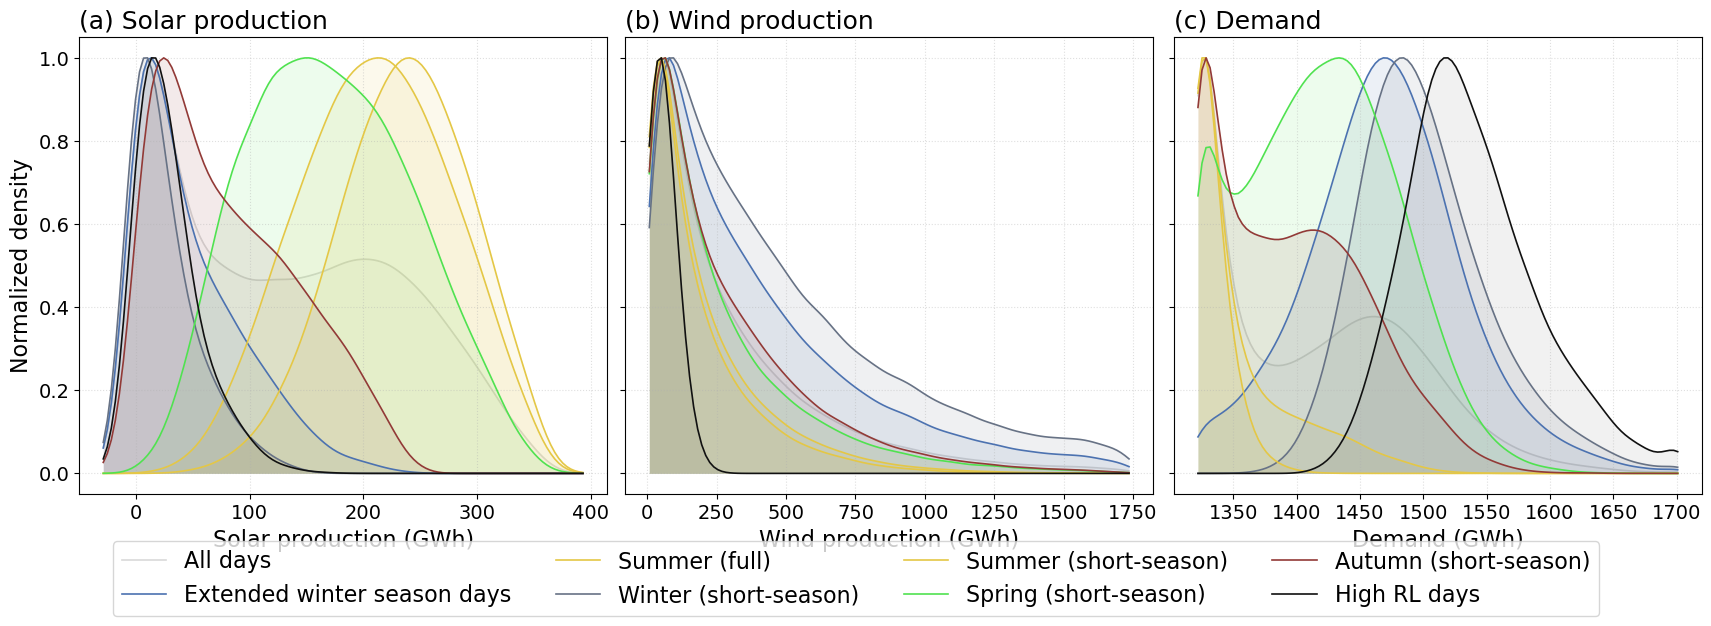

In [8]:
# variables and appearance
columns = [('solar_prod_adj','(a) Solar production', 'Solar production (GWh)'), ('wind_total','(b) Wind production', 'Wind production (GWh)'), ('demand','(c) Demand', 'Demand (GWh)')]  # cols and pretty names
bins = 120  # number of histogram bins
smooth_sigma = 3  # smoothing bandwidth (larger = smoother)
figsize = (17,5.5)  # figure size
color_all, color_winter, color_filtered = '#d9d9d9','#4c72b0','#111111'  # colors
lw = 1.2  # line width
fill_alpha = 0.10  # fill transparency

# helper: gaussian kernel (precompute once) ------------------------------------------------
kernel_half = max(1, int(3*smooth_sigma))  # half-width of kernel
k_x = np.arange(-kernel_half, kernel_half+1)  # kernel x coords
kernel = np.exp(-0.5*(k_x/smooth_sigma)**2)  # gaussian weights
kernel = kernel / kernel.sum()  # normalize kernel to sum=1
# -----------------------------------------------------------------------------------------


# make text bigger (global)
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})
# plotting (updated to include all requested datasets; per-curve peak normalization, density=True)
fig, axes = plt.subplots(1, 3, figsize=figsize, constrained_layout=True, sharey=True)  # 3 subplots in a row

for ax, (col, title, xaxis) in zip(axes, columns):
    a = df[col].values  # all data array
    w = df_winter[col].values  # winter array
    su = df_summer[col].values  # summer (full) array
    ws_short = df_winter_short[col].values  # winter short-season array
    ss_short = df_summer_short[col].values  # summer short-season array
    spr_short = df_spring_short[col].values  # spring short-season array
    aut_short = df_autumn_short[col].values  # autumn short-season array
    f = df_filtered[col].values  # filtered/high-RL array

    # common bin edges spanning min..max across all sets so curves align
    combined_min = min(a.min(), w.min(), su.min(), ws_short.min(), ss_short.min(), spr_short.min(), aut_short.min(), f.min())
    combined_max = max(a.max(), w.max(), su.max(), ws_short.max(), ss_short.max(), spr_short.max(), aut_short.max(), f.max())
    edges = np.linspace(combined_min, combined_max, bins+1)  # bin edges
    centers = (edges[:-1] + edges[1:]) / 2.0  # bin centers

    # histogram densities (density=True -> density per unit)
    ca, _ = np.histogram(a, bins=edges, density=True)       # density for all
    cw, _ = np.histogram(w, bins=edges, density=True)       # density for winter
    csu, _ = np.histogram(su, bins=edges, density=True)     # density for summer (full)
    cws_short, _ = np.histogram(ws_short, bins=edges, density=True)  # density for winter short
    css_short, _ = np.histogram(ss_short, bins=edges, density=True)  # density for summer short
    cspr_short, _ = np.histogram(spr_short, bins=edges, density=True) # density for spring short
    caut_short, _ = np.histogram(aut_short, bins=edges, density=True) # density for autumn short
    cf, _ = np.histogram(f, bins=edges, density=True)       # density for filtered

    # smooth densities by convolving with the gaussian kernel
    sa = np.convolve(ca, kernel, mode='same')       # smoothed all
    sw = np.convolve(cw, kernel, mode='same')       # smoothed winter
    ssu = np.convolve(csu, kernel, mode='same')     # smoothed summer (full)
    sws_short = np.convolve(cws_short, kernel, mode='same')  # smoothed winter short
    sss_short = np.convolve(css_short, kernel, mode='same')  # smoothed summer short
    sspr_short = np.convolve(cspr_short, kernel, mode='same')# smoothed spring short
    saut_short = np.convolve(caut_short, kernel, mode='same')# smoothed autumn short
    sf = np.convolve(cf, kernel, mode='same')       # smoothed filtered

    # normalize each curve to its own peak so every curve's max == 1
    sa /= max(sa.max(), 1e-12)     # normalize all
    sw /= max(sw.max(), 1e-12)     # normalize winter
    ssu /= max(ssu.max(), 1e-12)   # normalize summer (full)
    sws_short /= max(sws_short.max(), 1e-12)   # normalize winter short
    sss_short /= max(sss_short.max(), 1e-12)   # normalize summer short
    sspr_short /= max(sspr_short.max(), 1e-12) # normalize spring short
    saut_short /= max(saut_short.max(), 1e-12) # normalize autumn short
    sf /= max(sf.max(), 1e-12)     # normalize filtered

    # plotting curves + fills
    ax.plot(centers, sa, lw=lw, color=color_all, label='All', zorder=1)  # all curve
    ax.fill_between(centers, sa, 0, color=color_all, alpha=fill_alpha, linewidth=0)  # fill all

    ax.plot(centers, sw, lw=lw, color=color_winter, label='Winter', zorder=2)  # winter curve
    ax.fill_between(centers, sw, 0, color=color_winter, alpha=fill_alpha, linewidth=0)  # fill winter

    ax.plot(centers, ssu, lw=lw, color=color_summer_short, label='Summer (full)', zorder=2)  # summer (full)
    ax.fill_between(centers, ssu, 0, color=color_summer_short, alpha=fill_alpha, linewidth=0)

    ax.plot(centers, sws_short, lw=lw, color=color_winter_short, label='Winter (short)', zorder=3)  # winter short
    ax.fill_between(centers, sws_short, 0, color=color_winter_short, alpha=fill_alpha, linewidth=0)

    ax.plot(centers, sss_short, lw=lw, color=color_summer_short, label='Summer (short)', zorder=3)  # summer short
    ax.fill_between(centers, sss_short, 0, color=color_summer_short, alpha=fill_alpha, linewidth=0)

    ax.plot(centers, sspr_short, lw=lw, color=color_spring_short, label='Spring (short)', zorder=3)  # spring short
    ax.fill_between(centers, sspr_short, 0, color=color_spring_short, alpha=fill_alpha, linewidth=0)

    ax.plot(centers, saut_short, lw=lw, color=color_autumn_short, label='Autumn (short)', zorder=3)  # autumn short
    ax.fill_between(centers, saut_short, 0, color=color_autumn_short, alpha=fill_alpha, linewidth=0)

    ax.plot(centers, sf, lw=lw, color=color_filtered, label='High RL', zorder=4)  # filtered curve
    ax.fill_between(centers, sf, 0, color=color_filtered, alpha=0.06, linewidth=0)  # fill filtered

    # labels and styling
    ax.set_title(title, loc='left')  # subplot title
    ax.set_xlabel(xaxis)  # x label
    if ax == axes[0]:
        ax.set_ylabel('Normalized density')  # y label
    ax.grid(True, linestyle=':', alpha=0.4)  # grid

# updated legend to include the additional datasets
legend_handles = [
    Line2D([0], [0], color=color_all, lw=lw, label='All days'),
    Line2D([0], [0], color=color_winter, lw=lw, label='Extended winter season days'),
    Line2D([0], [0], color=color_summer_short, lw=lw, label='Summer (full)'),
    Line2D([0], [0], color=color_winter_short, lw=lw, label='Winter (short-season)'),
    Line2D([0], [0], color=color_summer_short, lw=lw, label='Summer (short-season)'),
    Line2D([0], [0], color=color_spring_short, lw=lw, label='Spring (short-season)'),
    Line2D([0], [0], color=color_autumn_short, lw=lw, label='Autumn (short-season)'),
    Line2D([0], [0], color=color_filtered, lw=lw, label='High RL days'),
]
fig.subplots_adjust(bottom=0.18)  # make room for the legend
fig.legend(handles=legend_handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.13), fontsize=16, frameon=True)

plt.show()  # display
